# Bước 2: Phân tích Khám phá Dữ liệu (Exploratory Data Analysis - EDA)

Notebook này trực quan hóa phân phối của biến mục tiêu và các mối quan hệ tương quan trong dữ liệu.

In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, accuracy_score, classification_report, confusion_matrix

print("Imported necessary libraries successfully!")

Imported necessary libraries successfully!


In [2]:
# Đọc dữ liệu thô phục vụ vẽ biểu đồ
data_path = '../data/raw/Student_Performance.csv'
if not os.path.exists(data_path):
    data_path = 'data/raw/Student_Performance.csv'

df_raw = pd.read_csv(data_path)
df_raw.columns = df_raw.columns.str.strip()


### 1.2. Phân tích Khám phá Dữ liệu bằng Hình ảnh (Exploratory Data Analysis - EDA)

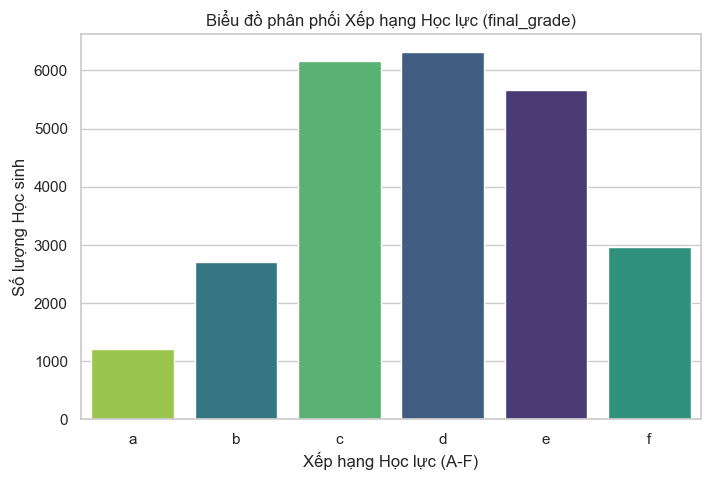

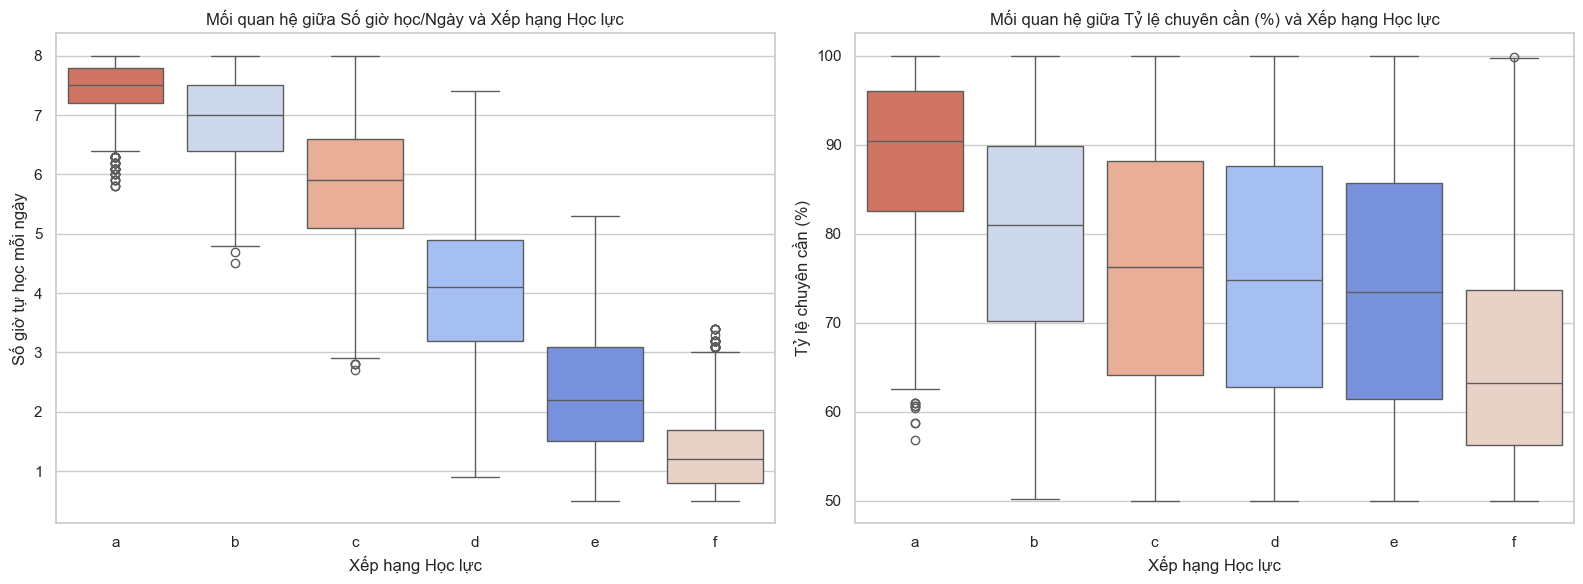

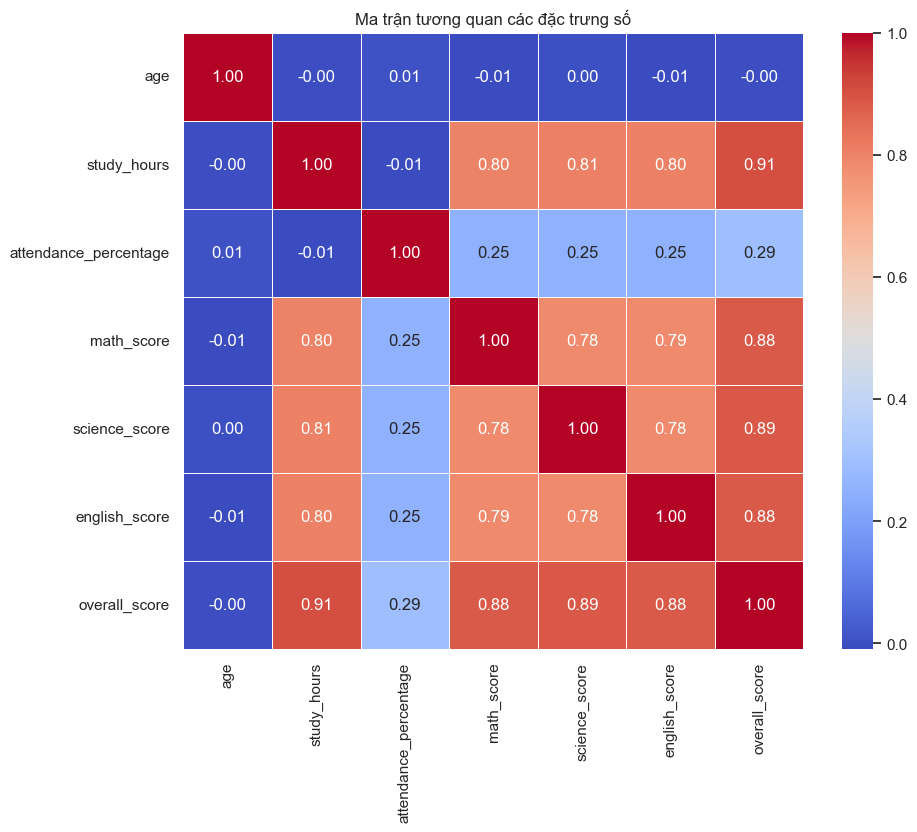

In [3]:
# Thiết lập cấu hình chung cho matplotlib/seaborn
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 1. Phân phối của biến mục tiêu final_grade (Xếp hạng học lực đa lớp)
plt.figure(figsize=(8, 5))
# Thêm hue='final_grade' và legend=False để tránh cảnh báo tương thích của Seaborn mới
sns.countplot(x='final_grade', hue='final_grade', data=df_raw, order=['a', 'b', 'c', 'd', 'e', 'f'], palette='viridis', legend=False)
plt.title('Biểu đồ phân phối Xếp hạng Học lực (final_grade)')
plt.xlabel('Xếp hạng Học lực (A-F)')
plt.ylabel('Số lượng Học sinh')
plt.show()

# 2. Khảo sát mối quan hệ giữa các yếu tố tác động chính (Số giờ học, Chuyên cần) và Xếp hạng Học lực
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(ax=axes[0], x='final_grade', y='study_hours', hue='final_grade', data=df_raw, order=['a', 'b', 'c', 'd', 'e', 'f'], palette='coolwarm', legend=False)
axes[0].set_title('Mối quan hệ giữa Số giờ học/Ngày và Xếp hạng Học lực')
axes[0].set_xlabel('Xếp hạng Học lực')
axes[0].set_ylabel('Số giờ tự học mỗi ngày')

sns.boxplot(ax=axes[1], x='final_grade', y='attendance_percentage', hue='final_grade', data=df_raw, order=['a', 'b', 'c', 'd', 'e', 'f'], palette='coolwarm', legend=False)
axes[1].set_title('Mối quan hệ giữa Tỷ lệ chuyên cần (%) và Xếp hạng Học lực')
axes[1].set_xlabel('Xếp hạng Học lực')
axes[1].set_ylabel('Tỷ lệ chuyên cần (%)')

plt.tight_layout()
plt.show()

# 3. Ma trận tương quan heatmap giữa các đặc trưng dạng số
numerical_cols = ['age', 'study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'overall_score']
plt.figure(figsize=(10, 8))
sns.heatmap(df_raw[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan các đặc trưng số')
plt.show()